# PART1_make_Haplotype_block

make haplotype blocks from SNP genotype data

In [1]:
import pandas as pd
import numpy as np
import glob
from sklearn.decomposition import PCA
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

from modules.make_Haplotype_block import make_Haplotype_block

# Generate Haplotype block

In [ ]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
genotype_path_list = glob.glob("../data/genotype_data/NAM_all_imputed_all_filtered_commpos_ALL_genotype_*")
out_path = "../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv"
make_Haplotype_block(family, family_list, genotype_path_list, out_path)

# Check the number of Haplotype Blocks

the number of original SNPs are 2267857

In [4]:
Haplotype_block = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")
print("The number of Haplotype blocks is ", Haplotype_block.shape[0])

The number of Haplotype blocks is  57085


# Clustering genotype

In [ ]:
# get haplotype genotype data
founder = pd.read_excel("../data/phenotype_data/Founders.xlsx")
genotype_data = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")
genotype_data = genotype_data.iloc[:, 3:]
genotype_data = genotype_data.T
genotype_data = genotype_data.fillna(1)
# remove genotype data of RILs that have no phenotype data
genotype_data = genotype_data.loc[~genotype_data.index.str.contains("N22"), :]

In [8]:
# PCA analysis
pca = PCA(n_components=2)
pca.fit(genotype_data)
feature = pca.transform(genotype_data)
feature = pd.DataFrame(feature, columns=["PC{}".format(x + 1) for x in range(2)])
feature.index = genotype_data.index.values
feature["RIL"] = [i[:3] for i in feature.index.values]
feature["group"] = [founder[founder.ID == i[:3]].group.values[0] for i in feature.index.values]

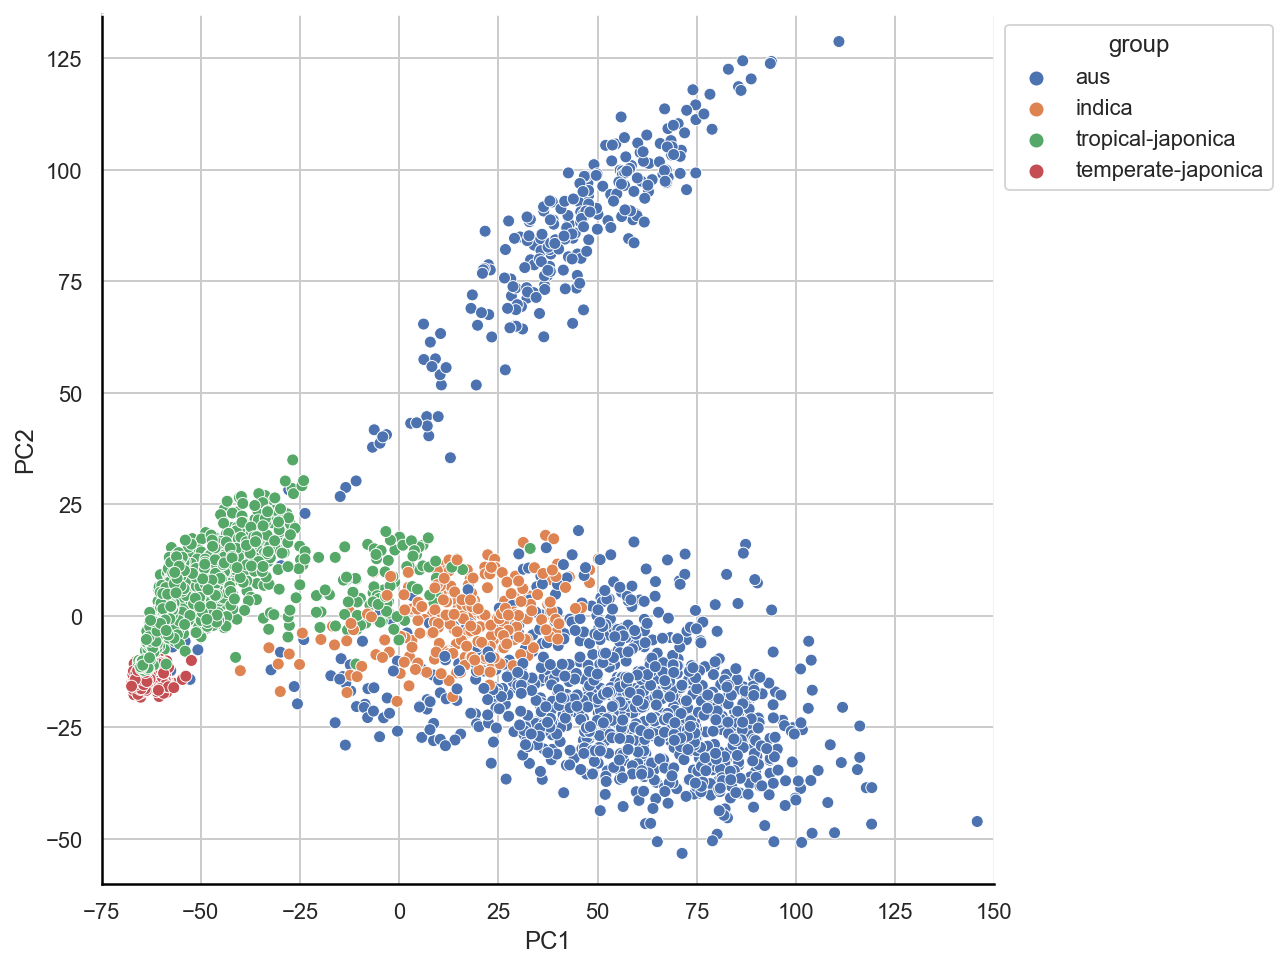

aus


<Figure size 432x288 with 0 Axes>

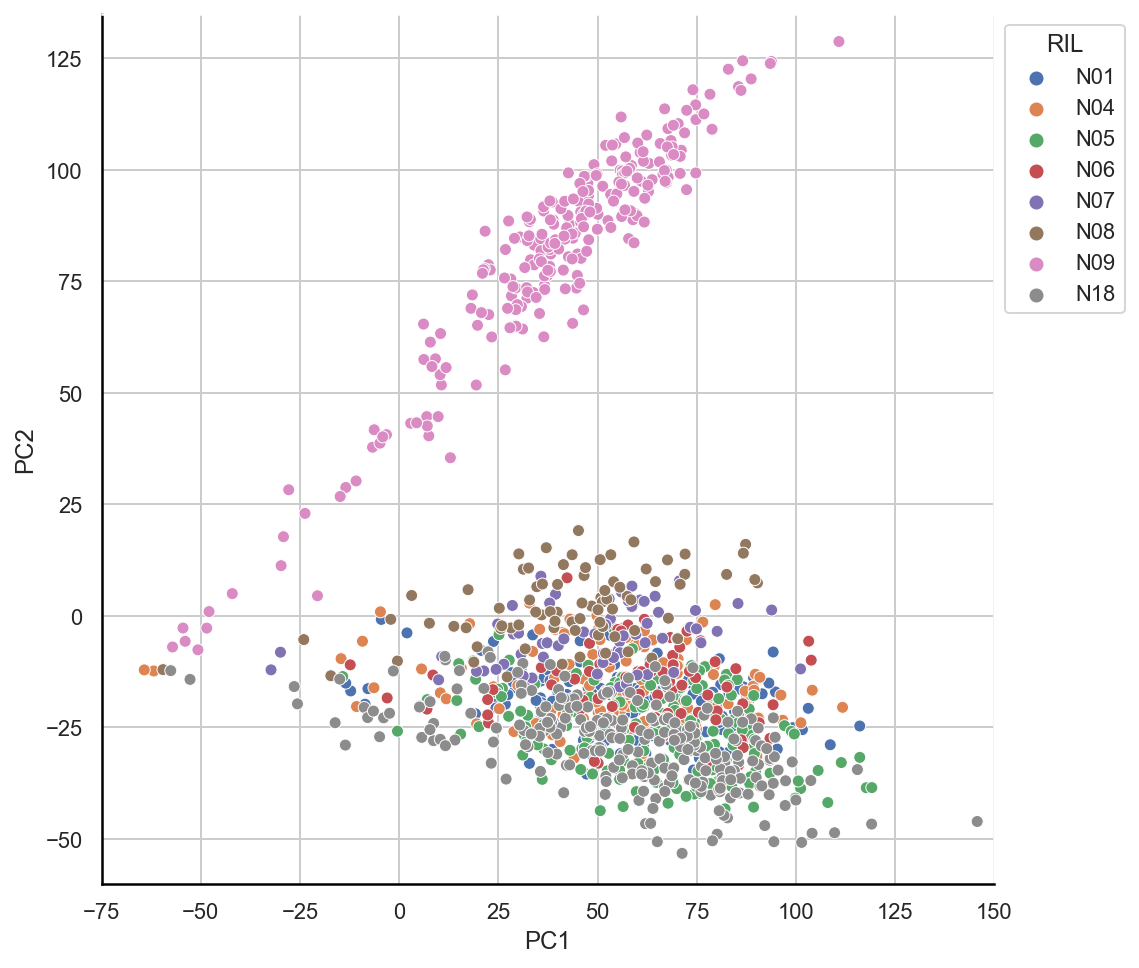

indica


<Figure size 432x288 with 0 Axes>

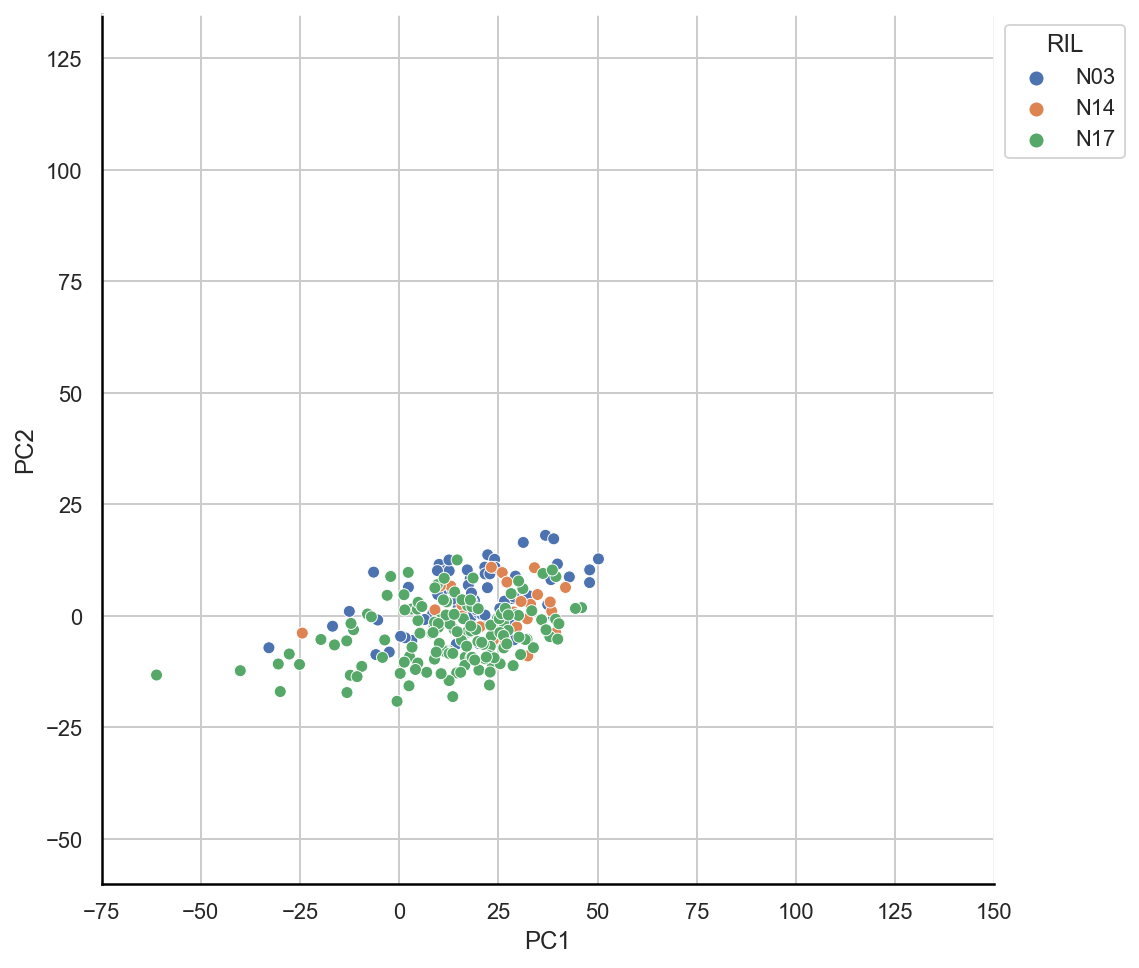

tropical-japonica


<Figure size 432x288 with 0 Axes>

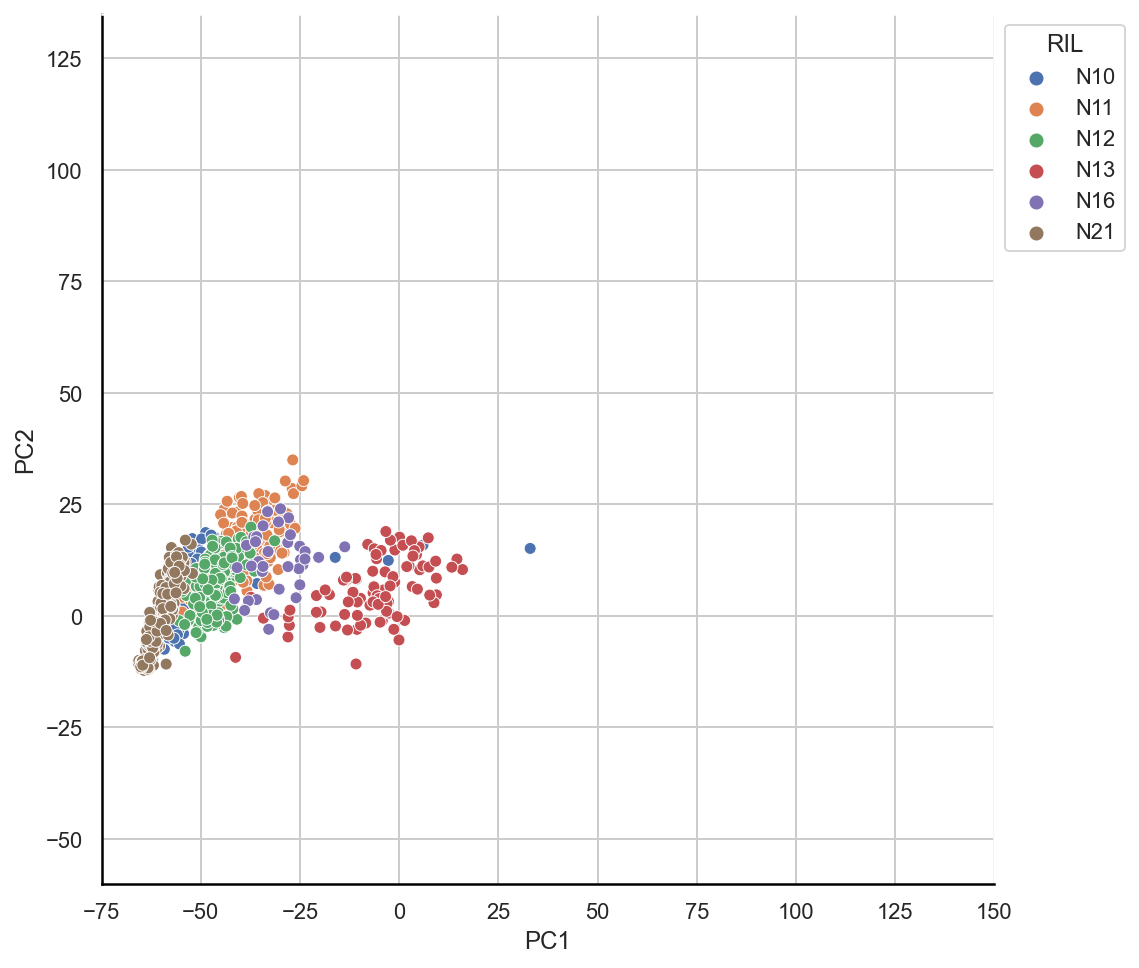

temperate-japonica


<Figure size 432x288 with 0 Axes>

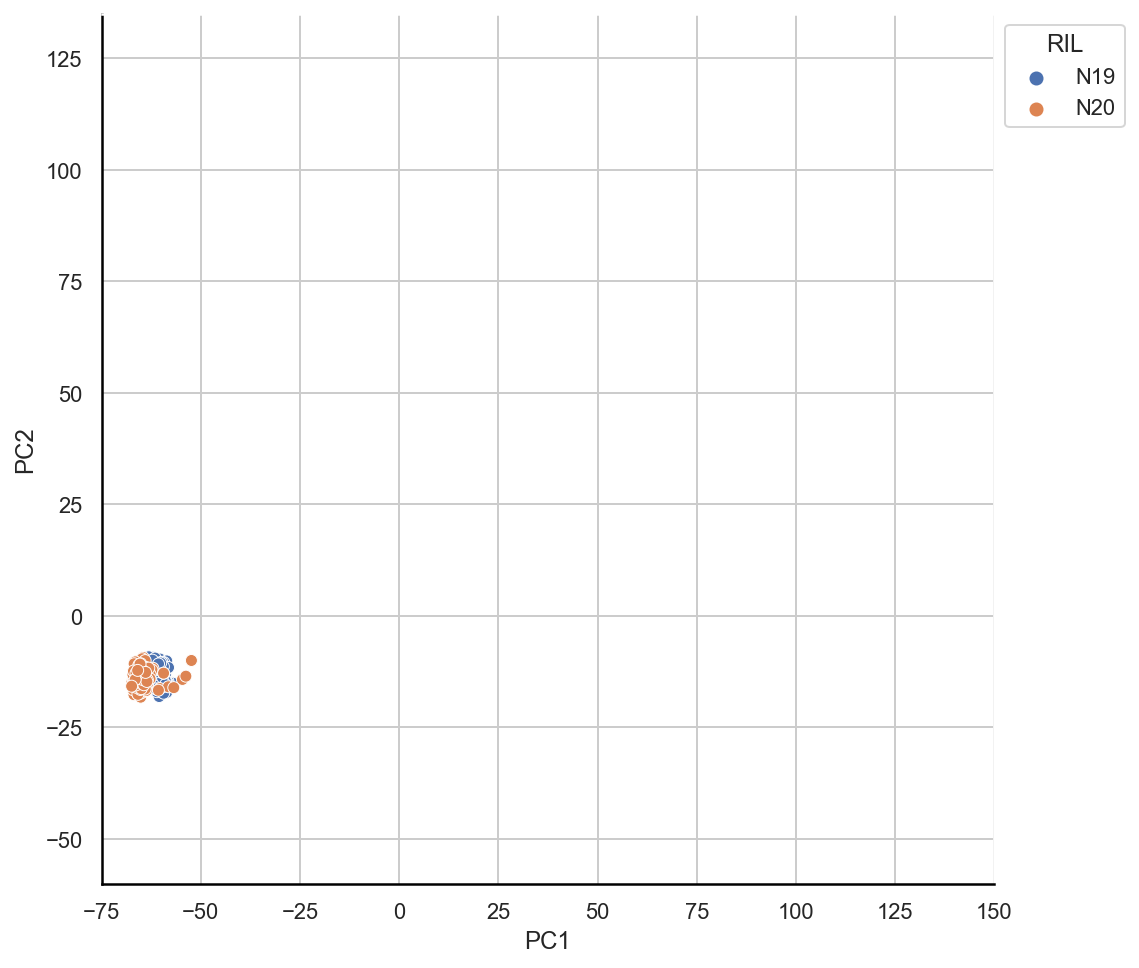

<Figure size 432x288 with 0 Axes>

In [12]:
sns.set(style='whitegrid', color_codes=True)
plt.figure(figsize=(8,8))

# visualize PC1, PC2 scatter plot for NAM population
ax = sns.scatterplot(data=feature, x="PC1", y="PC2", hue="group")
for sp in ["left", "bottom"]:
    ax.spines[sp].set_color('black')
for sp in ["right", "top"]:
    ax.spines[sp].set_color('white')
plt.xlim(-75, 150)
plt.ylim(-60, 135)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()
plt.clf()

# visualize PC1, PC2 scatter plot for each group
for each_group in ["aus", "indica", "tropical-japonica", "temperate-japonica"]:
    print(each_group)
    plt.figure(figsize=(8,8))
    ax = sns.scatterplot(data=feature[feature.group == each_group], x="PC1", y="PC2", hue="RIL")
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_color('black')
    for sp in ["right", "top"]:
        ax.spines[sp].set_color('white')
    plt.xlim(-75, 150)
    plt.ylim(-60, 135)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.show()
    plt.clf()

# Clustering phenotype

In [13]:
phenotype_data = pd.read_csv("../data/phenotype_data/mean_phenotypes.csv", index_col=0)
phenotype_data = phenotype_data.iloc[:, [0,1,2,3,4,5,8]]
phenotype_data = phenotype_data.dropna()
phenotype_data = phenotype_data.set_index("Line")
phenotype_data["group"] = [founder[founder.ID == i[:3]].group.values[0] for i in phenotype_data.index.values]
phenotype_data["RIL"] = [i[:3] for i in phenotype_data.index.values]

,LW_mean,GN_mean,LL_mean,DTH_mean,PN_mean,Area.size.AS..mm2.,group,RIL
Line,,,,,,,,
N01_001,1.2750,142.883333,35.200,113.8,12.833333,13.208899,aus,N01
N01_002,1.1375,116.066667,32.975,107.6,13.833333,12.521728,aus,N01
N01_003,1.3125,118.150000,30.750,113.0,11.166667,16.895262,aus,N01
N01_004,1.1125,154.450000,37.475,123.2,16.500000,12.149159,aus,N01
N01_005,1.5000,128.816667,29.725,115.8,13.000000,14.092787,aus,N01


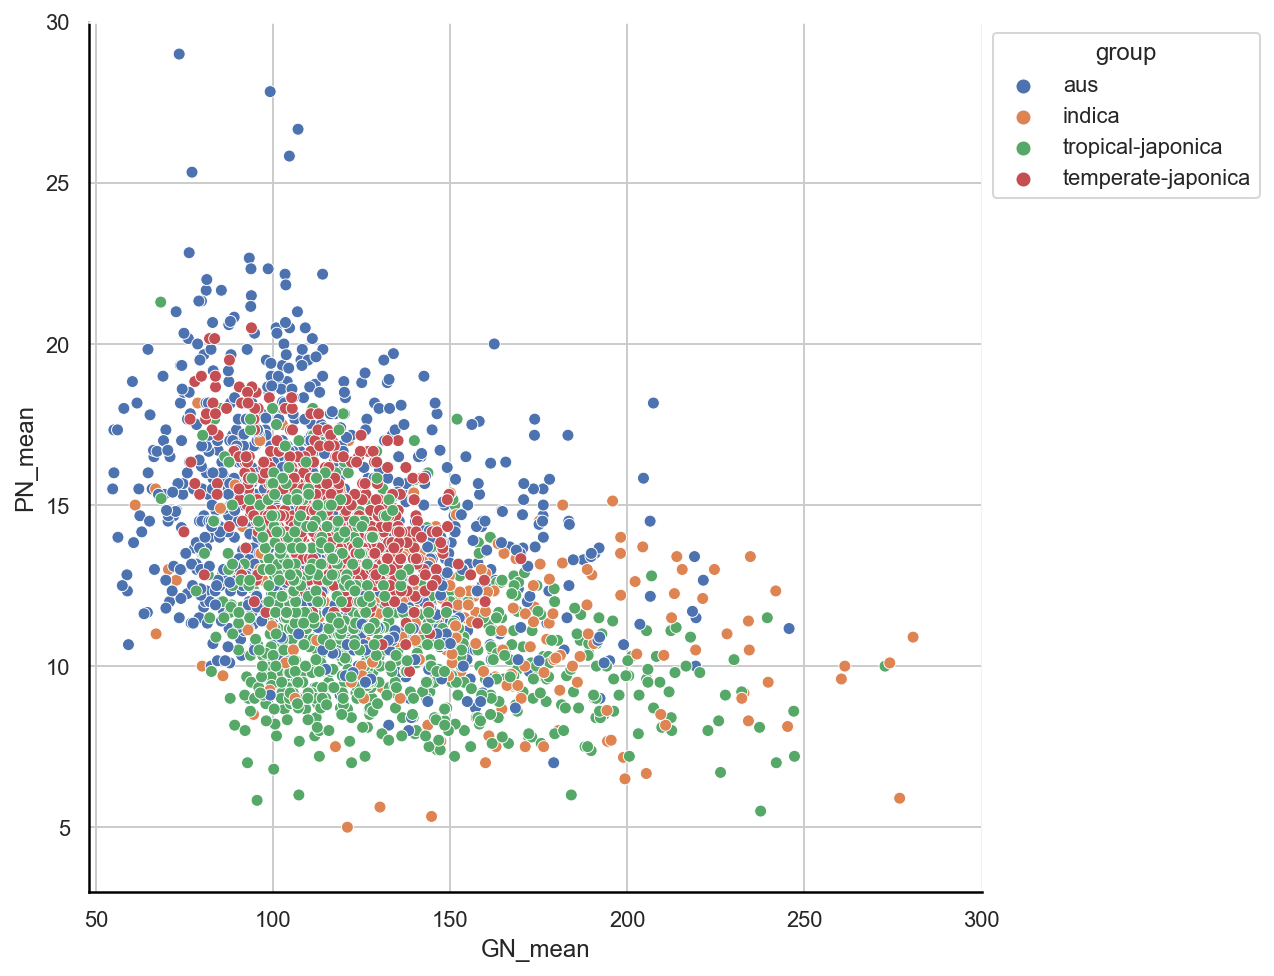

aus


<Figure size 432x288 with 0 Axes>

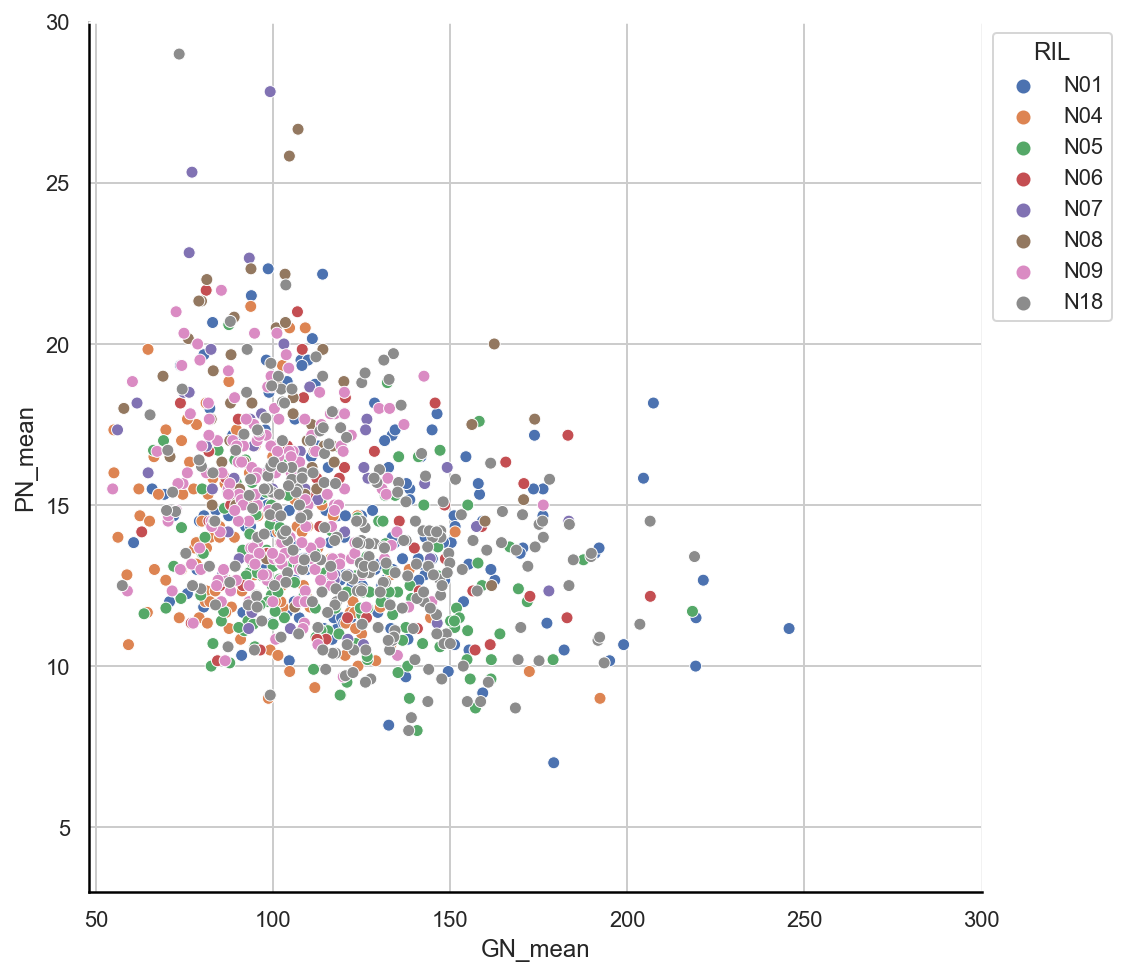

indica


<Figure size 432x288 with 0 Axes>

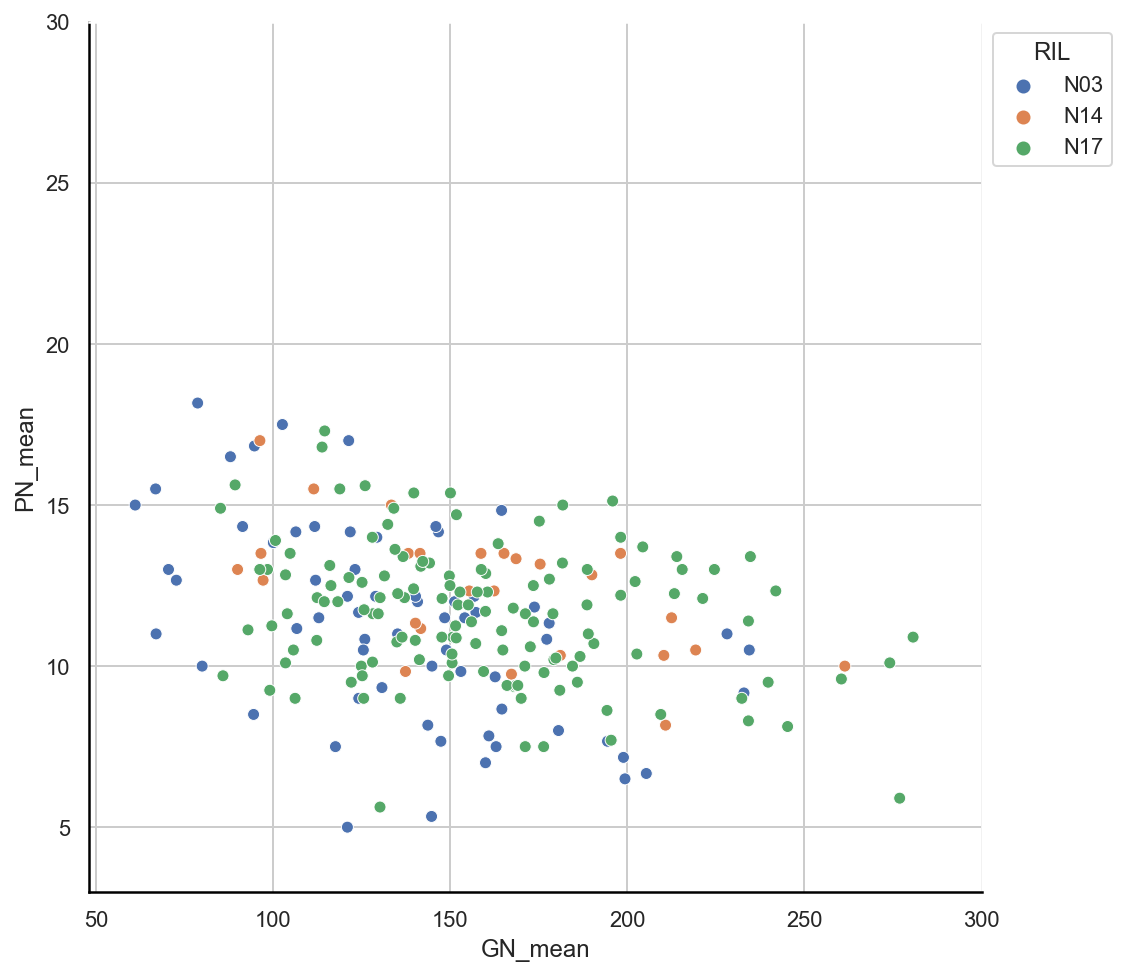

tropical-japonica


<Figure size 432x288 with 0 Axes>

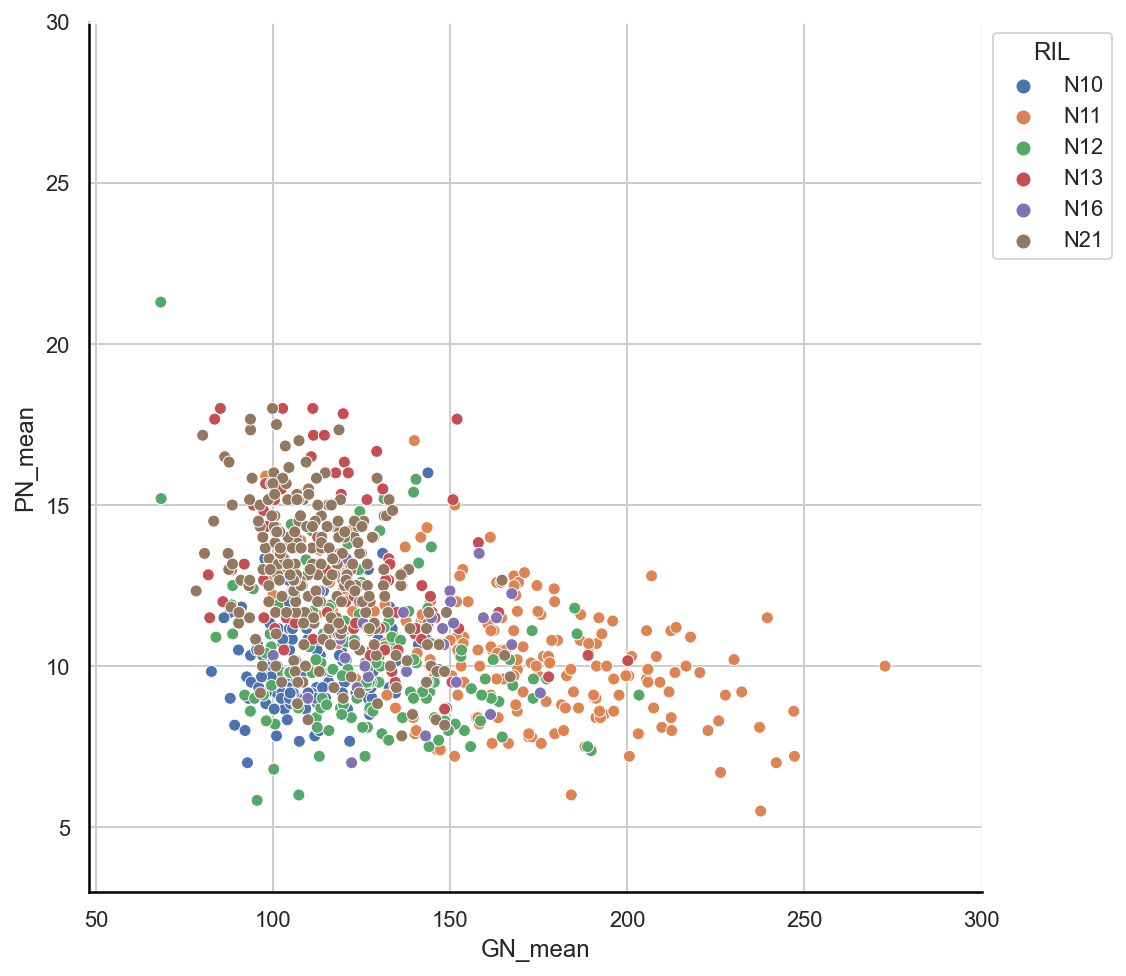

temperate-japonica


<Figure size 432x288 with 0 Axes>

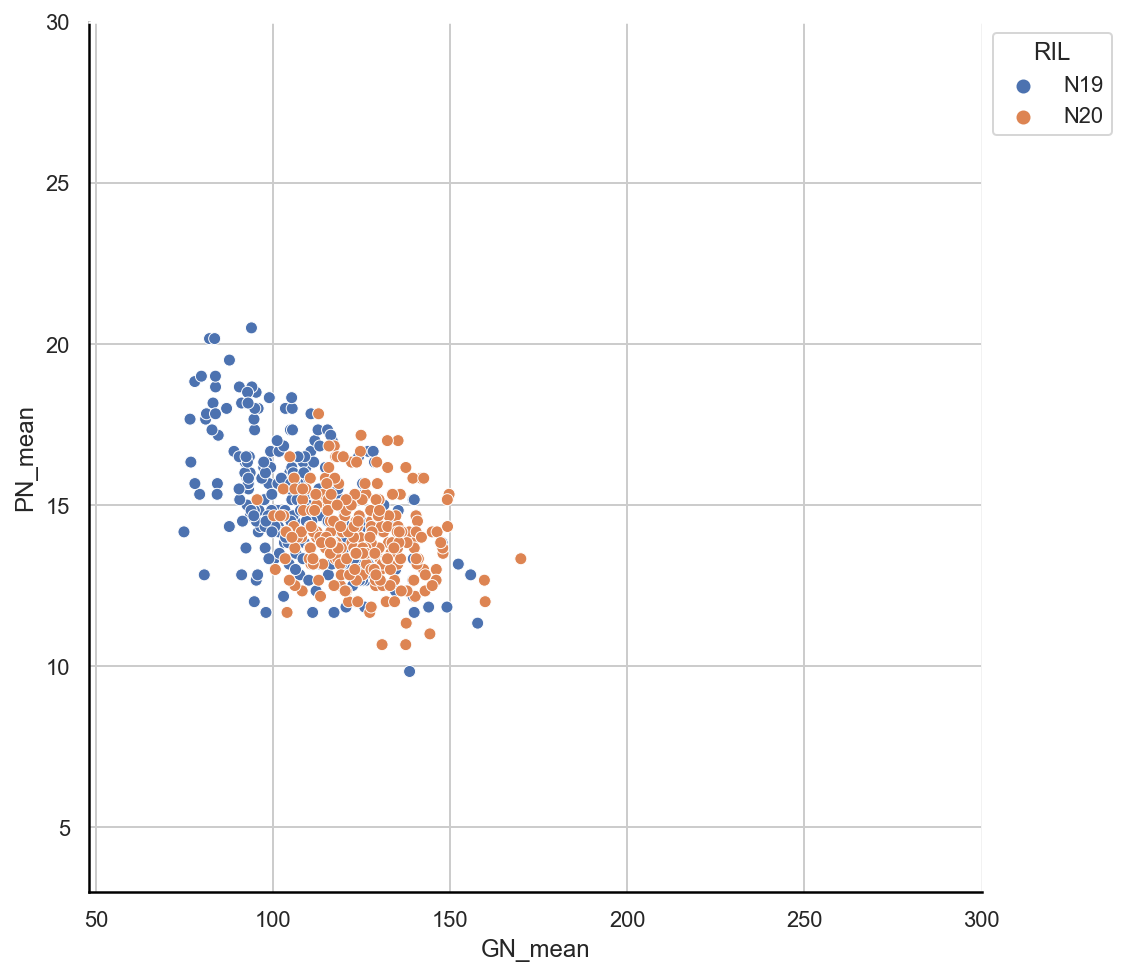

<Figure size 432x288 with 0 Axes>

In [14]:
sns.set(style='whitegrid', color_codes=True)
plt.figure(figsize=(8,8))

# visualize GN, PN scatter plot for NAM population
ax = sns.scatterplot(data=phenotype_data, x="GN_mean", y="PN_mean", hue="group")
for sp in ["left", "bottom"]:
    ax.spines[sp].set_color('black')
for sp in ["right", "top"]:
    ax.spines[sp].set_color('white')
plt.xlim(48, 300)
plt.ylim(3, 30)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()
plt.clf()

# visualize GN, PN scatter plot for each group
for each_group in ["aus", "indica", "tropical-japonica", "temperate-japonica"]:
    print(each_group)
    plt.figure(figsize=(8,8))
    ax = sns.scatterplot(data=phenotype_data[phenotype_data.group == each_group], x="GN_mean", y="PN_mean", hue="RIL")
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_color('black')
    for sp in ["right", "top"]:
        ax.spines[sp].set_color('white')
    plt.xlim(48, 300)
    plt.ylim(3, 30)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.show()
    plt.clf()